In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import DistributedOptimizerAgent
from ant.centralised import P4

In [4]:
market_seed = 21234
graph_seed = 1
market_size = 80
cavement_div = 5
ks = [
   1,
    # 2,
    # 3,
    # 4,
    # 5,
    # 6
]
graphs = {
    # "Ladder": nx.circular_ladder_graph(int(market_size / 2)),
    # "Scale-free": nx.barabasi_albert_graph(market_size, 1, seed=graph_seed),
    # "Small-World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=graph_seed),
    "Caveman": nx.connected_caveman_graph(int(market_size / cavement_div), cavement_div)
}

markets = {}

for graph_type in graphs.keys():
    markets[graph_type] = []
    for optimizer_k in ks:
        _market = Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=DistributedOptimizerAgent, k=optimizer_k)
        markets[graph_type].append({
            "agent_strategy": "Distributed Optimizer",
            "k": optimizer_k,
            "graph_type": graph_type,
            "market": _market,
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        })
    # benchmark
    markets[graph_type].append({
            "agent_strategy": "Proportional",
            "k": None,
            "market": Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=ProportionalAgent),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        })
    markets[graph_type].append({
            "agent_strategy": "Optimal",
            "k": None,
            "market": Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=OptimalAgent),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        })


In [5]:
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["optimal_allocations"], entry["utility_vector"] = P4(entry["market"])
        entry["market"].set_market_equilibrium(entry["optimal_allocations"], entry["utility_vector"])

In [6]:
simulation_duration = 40
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["simulation_result"] = entry["market"].simulate(simulation_duration, use_average_in_market_loss=True, return_utility_instead_of_market_loss=False)
        if entry["agent_strategy"] == "Optimizer":
            health = sum([1 if not agent.has_crashed else 0 for agent in entry["market"].agents]) / len(entry["market"])
            print(f"{graph_type}, k={entry['k']} health: {int(health*100)}%")

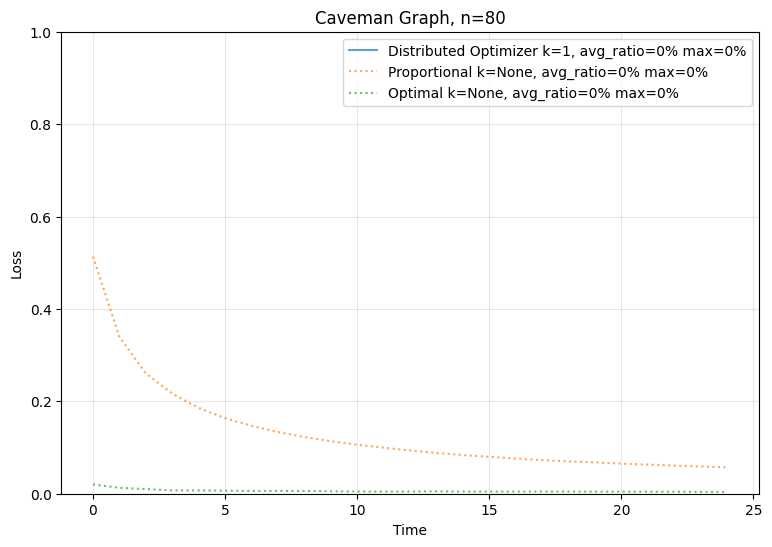

In [7]:
window = (5, min(simulation_duration, 50))
window = (0, 25)
time_steps = np.arange(window[0], window[1])
benchmarks = ["Optimal", "Proportional"]

k_mask = [
    # 1,
    # 2,
    # 3,
    # 4,
    # 5
]
agent_mask = [
    # "Optimal"
]

def filter(array):
    mutated = np.array(array)
    mean = np.mean(mutated[mutated <= 1.0])
    mutated[mutated > 1.0] = None
    n_fixed = array[array > 1.0].size
    if n_fixed > 0:
        print(f"removed {n_fixed} values")
    return mutated

for graph_type in markets.keys():
    plt.figure(figsize=(9, 6))
    axis = plt.gca()
    axis.set_ylim(0.0, 1.0)

    for entry in markets[graph_type]:
        if entry["k"] in k_mask or entry["agent_strategy"] in agent_mask:
            continue
        data = entry["simulation_result"][window[0]:window[1]]
        # data = filter(data)
        avg_ratio_prct = int(entry['avg_market_ratio']*100) if entry['avg_market_ratio'] is not None else 0
        max_ratio_prct = int(entry['max_market_ratio']*100) if entry['avg_market_ratio'] is not None else 0
        plt.plot(
            time_steps,
            data,
            label=f"{entry['agent_strategy']} k={entry['k']}, avg_ratio={avg_ratio_prct}% max={max_ratio_prct}%",
            alpha=0.7,
            linestyle="-" if entry['agent_strategy'] not in benchmarks else ":",
        )
        # plt.axhline(y=np.sum(entry["utility_vector"]), color='red', linestyle='--', linewidth=2, label='Optimal utility')
        # plt.axhline(y=np.mean(entry["simulation_result"]), color='blue', linestyle='--', linewidth=2, label='Avg utility')
    plt.xlabel("Time")
    plt.ylabel("Loss")
    plt.title(f"{graph_type} Graph, n={market_size}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()